# Graph-GradCAM explanation for MCI classification on NNConv model

In [1]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00


In [ ]:
import re
import os
import torch
import torch.nn as nn
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from torch_geometric.data import Data, Batch
from torch_geometric.nn import global_mean_pool, global_max_pool
from google.colab import drive

In [3]:
drive.mount('/content/drive')

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Mounted at /content/drive
Using device: cpu


### Model definition

In [4]:
class NNConvLayer(nn.Module):
    def __init__(self, node_dim, edge_dim, out_dim):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, node_dim * out_dim)
        )
        self.node_dim = node_dim
        self.out_dim  = out_dim
        self.gru = nn.GRUCell(out_dim, node_dim)

    def forward(self, x, edge_index, edge_attr):
        src, dst = edge_index
        num_nodes = x.size(0)
        W = self.edge_mlp(edge_attr).view(-1, self.node_dim, self.out_dim)
        h_src = x[src].unsqueeze(1)
        msg   = torch.bmm(h_src, W).squeeze(1)
        agg   = torch.zeros(num_nodes, self.out_dim, device=x.device)
        agg.scatter_add_(0, dst.unsqueeze(-1).expand_as(msg), msg)
        return self.gru(agg, x)


class NNConvNet(nn.Module):
    def __init__(self, node_in, edge_in, hidden, dropout):
        super().__init__()
        self.input_proj = nn.Linear(node_in, hidden)
        self.input_norm = nn.BatchNorm1d(hidden)
        self.conv1 = NNConvLayer(hidden, edge_in, hidden)
        self.norm1 = nn.BatchNorm1d(hidden)
        self.conv2 = NNConvLayer(hidden, edge_in, hidden)
        self.norm2 = nn.BatchNorm1d(hidden)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.input_proj(x)
        x = self.input_norm(x)
        x = x.relu()
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = x.relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = x.relu()
        x = self.dropout(x)
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=-1)
        return self.classifier(x)

### Defining paths, feature names, and loading best model

In [5]:
MODEL_PATH = '/content/drive/MyDrive/team3_xai_gnn/nnconv_results/outer_checkpoints/cfg00_outer1.pt'
TEST_PATH  = '/content/drive/MyDrive/team3_xai_gnn/preprocessed/fold_1_test.pt'
DMRI_PATH  = '/content/drive/MyDrive/team3_xai_gnn/oasis3_graphmls_scale1'

NODE_FEATURE_NAMES = ['volume', 'thickness', 'has_volume', 'has_thickness']

model = NNConvNet(node_in=4, edge_in=15, hidden=32, dropout=0.3)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()
print('Model loaded.')

Model loaded.


### Building a map to lookup ROI indexes and find their names

In [6]:
test_graphs = torch.load(TEST_PATH, map_location=device, weights_only=False)
mci_graphs  = [g for g in test_graphs if g.y.item() == 1]
cn_graphs   = [g for g in test_graphs if g.y.item() == 0]
print(f'Test subjects: {len(test_graphs)}  |  MCI: {len(mci_graphs)}  |  CN: {len(cn_graphs)}')

graphml_files = [f for f in os.listdir(DMRI_PATH) if f.endswith('.graphml')]
sample_G      = nx.read_graphml(os.path.join(DMRI_PATH, graphml_files[0]))
sample_G.remove_edges_from(list(nx.selfloop_edges(sample_G)))
nodes       = list(sample_G.nodes(data=True))
node_labels = {i: attrs.get('dn_name', f'node_{i}').strip() for i, (_, attrs) in enumerate(nodes)}
print(f'Node label map built: {len(node_labels)} ROIs')

Test subjects: 127  |  MCI: 22  |  CN: 105
Node label map built: 124 ROIs


### Graph GradCAM functions

In [7]:
def run_graphgradcam(subject, target_class):
    '''
    Computes GraphGradCAM node importance scores for a single subject.

    subject      : PyG Data object
    target_class : 0 = CN, 1 = MCI

    Returns:
        cam_scores : np.ndarray of shape (num_nodes,) - one score per ROI
                     higher means more important for the prediction
    '''
    model.eval()
    subject = subject.to(device)
    batch   = torch.zeros(subject.x.size(0), dtype=torch.long, device=device)

    activations = {}
    gradients   = {}

    # hook into the full conv2 layer output (more reliable than hooking conv2.gru directly)
    def forward_hook(module, input, output):
        activations['conv2'] = output  # (num_nodes, hidden)

    def backward_hook(module, grad_input, grad_output):
        gradients['conv2'] = grad_output[0]  # (num_nodes, hidden)

    fwd_handle = model.conv2.register_forward_hook(forward_hook)
    bwd_handle = model.conv2.register_full_backward_hook(backward_hook)

    logits = model(subject.x, subject.edge_index, subject.edge_attr, batch)

    model.zero_grad()
    logits[0, target_class].backward()

    fwd_handle.remove()
    bwd_handle.remove()

    H = activations['conv2'].detach()
    G = gradients['conv2'].detach()

    cam = torch.relu((H * G).sum(dim=-1))  # (num_nodes,)
    cam_scores = cam.cpu().numpy()

    if cam_scores.max() > 0:
        cam_scores = cam_scores / cam_scores.max()

    return cam_scores


def get_prediction(g):
    '''
    Returns (pred_class, prob_cn, prob_mci) for a graph.
    '''
    g = g.to(device)
    batch = torch.zeros(g.x.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        logits = model(g.x, g.edge_index, g.edge_attr, batch)
        probs  = torch.softmax(logits, dim=-1)
        pred   = logits.argmax(dim=-1).item()
    return pred, probs[0, 0].item(), probs[0, 1].item()


print('GraphGradCAM functions ready.')

GraphGradCAM functions ready.


### Helper functions for plots

In [8]:
def get_top_nodes(node_importance, node_labels, top_n=10):
    top_idx    = np.argsort(node_importance)[::-1][:top_n]
    top_names  = [node_labels[i] for i in top_idx]
    top_scores = node_importance[top_idx]
    return top_idx, top_names, top_scores


def plot_top_nodes(ax, names, scores, title, color):
    names  = list(names[::-1])
    scores = list(scores[::-1])
    bars   = ax.barh(names, scores, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('GraphGradCAM Score (normalised)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + max(scores) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{score:.4f}', va='center', fontsize=8)


def plot_score_distribution(ax, cam_scores, title, color):
    '''
    Histogram of CAM scores across all 124 nodes.
    Reveals whether importance is concentrated (few nodes dominate)
    or distributed (many nodes contribute equally).
    '''
    ax.hist(cam_scores, bins=20, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('GraphGradCAM Score', fontsize=10)
    ax.set_ylabel('Number of nodes', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    nonzero = (cam_scores > 0).sum()
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.text(0.98, 0.95, f'{nonzero}/{len(cam_scores)} nodes active',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)


def run_full_analysis(subject, true_label, pred_label, outcome_tag):
    '''
    Runs GraphGradCAM and produces plots for a single subject.
    target_class is always the predicted class — GradCAM explains
    what the model saw, not whether it was right.
    '''
    class_names  = {0: 'CN', 1: 'MCI'}
    cam_scores   = run_graphgradcam(subject, target_class=pred_label)
    _, top_names, top_scores = get_top_nodes(cam_scores, node_labels)

    title_base = (f'{outcome_tag} | {subject.subject_id} | '
                  f'True: {class_names[true_label]} - Pred: {class_names[pred_label]}')

    print(f'\n{title_base}')
    print(f'  Active nodes (score > 0): {(cam_scores > 0).sum()} / {len(cam_scores)}')
    print('  Top 10 ROIs:')
    for rank, (name, score) in enumerate(zip(top_names, top_scores)):
        print(f'    Rank {rank+1:02d} | {name:<45s} | {score:.6f}')

    colors = {'TP': '#d62728', 'TN': '#1f77b4', 'FP': '#ff7f0e', 'FN': '#9467bd'}
    c = colors[outcome_tag]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_top_nodes(axes[0], top_names, top_scores,
                   f'{title_base}\nTop 10 ROIs by GraphGradCAM', c)
    plot_score_distribution(axes[1], cam_scores,
                            f'{title_base}\nCAM Score Distribution across all ROIs', c)
    plt.tight_layout()
    plt.show()

    return cam_scores


print('Plotting helpers ready.')

Plotting helpers ready.


### Classifying all test subjects from the according outer fold and picking the most confident TP, TN, FP, FN ones

In [9]:
results = []
for g in test_graphs:
    pred, prob_cn, prob_mci = get_prediction(g)
    true = g.y.item()
    results.append((g, true, pred, prob_mci))

# sort each group by confidence (most convincing case first)
TP = sorted([(g, t, p, s) for g, t, p, s in results if t == 1 and p == 1], key=lambda x: -x[3])
TN = sorted([(g, t, p, s) for g, t, p, s in results if t == 0 and p == 0], key=lambda x:  x[3])
FP = sorted([(g, t, p, s) for g, t, p, s in results if t == 0 and p == 1], key=lambda x: -x[3])
FN = sorted([(g, t, p, s) for g, t, p, s in results if t == 1 and p == 0], key=lambda x:  x[3])

print(f'TP: {len(TP)}  TN: {len(TN)}  FP: {len(FP)}  FN: {len(FN)}')
for tag, pool in [('TP', TP), ('TN', TN), ('FP', FP), ('FN', FN)]:
    if pool:
        g, t, p, s = pool[0]
        print(f'  Most confident {tag}: {g.subject_id}  P(MCI)={s:.4f}')

TP: 14  TN: 87  FP: 18  FN: 8
  Most confident TP: OAS31004  P(MCI)=0.6972
  Most confident TN: OAS30723  P(MCI)=0.2792
  Most confident FP: OAS30443  P(MCI)=0.7888
  Most confident FN: OAS31050  P(MCI)=0.3662


### Graph GradCAM analysis on most confident subjects


----------------------------------------------------------------------------------------------------

TP | OAS31004 | True: MCI - Pred: MCI
  Active nodes (score > 0): 12 / 124
  Top 10 ROIs:
    Rank 01 | ctx-rh-pericalcarine                          | 1.000000
    Rank 02 | Right-Ventral_Anterior                        | 0.655417
    Rank 03 | ctx-lh-entorhinal                             | 0.517689
    Rank 04 | ctx-rh-parsorbitalis                          | 0.178290
    Rank 05 | ctx-rh-caudalanteriorcingulate                | 0.108680
    Rank 06 | ctx-rh-parahippocampal                        | 0.067400
    Rank 07 | ctx-rh-middletemporal                         | 0.050578
    Rank 08 | ctx-lh-lateraloccipital                       | 0.013482
    Rank 09 | ctx-lh-fusiform                               | 0.010961
    Rank 10 | Right-Pallidum                                | 0.008524


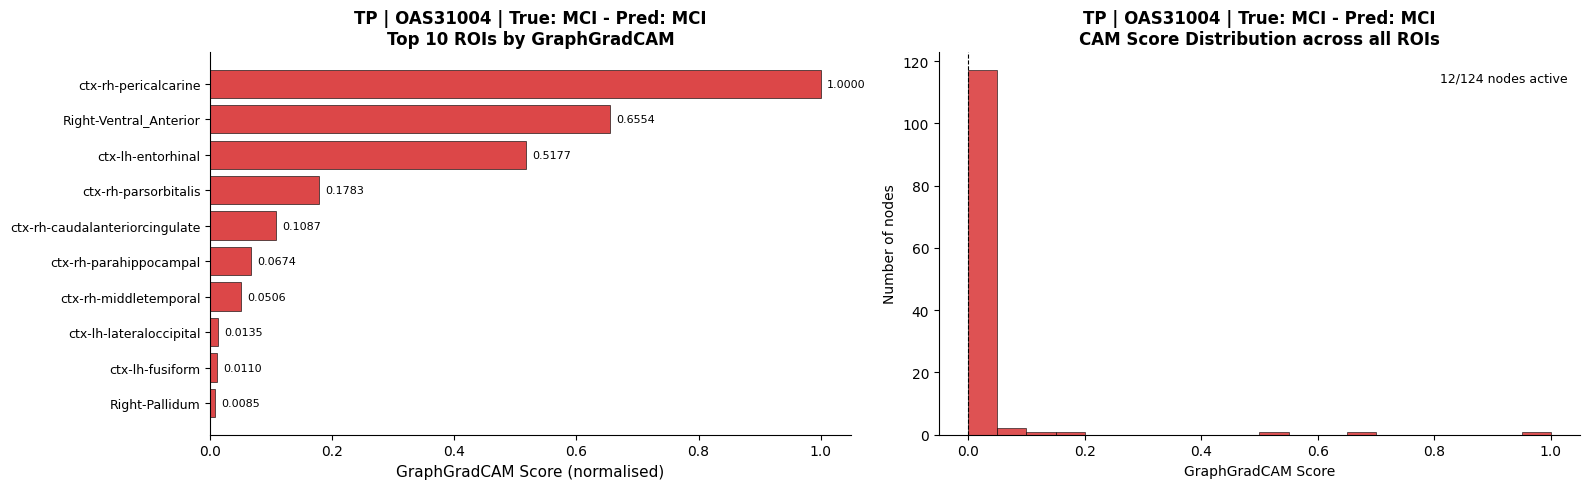


----------------------------------------------------------------------------------------------------

TN | OAS30723 | True: CN - Pred: CN
  Active nodes (score > 0): 63 / 124
  Top 10 ROIs:
    Rank 01 | ctx-rh-supramarginal                          | 1.000000
    Rank 02 | Left-Ventral_Anterior                         | 0.881780
    Rank 03 | ctx-lh-entorhinal                             | 0.855322
    Rank 04 | Left-Putamen                                  | 0.754832
    Rank 05 | ctx-rh-parstriangularis                       | 0.481383
    Rank 06 | ctx-rh-cuneus                                 | 0.285091
    Rank 07 | Left-Anterior                                 | 0.048103
    Rank 08 | ctx-rh-transversetemporal                     | 0.042355
    Rank 09 | Right-VentralDC                               | 0.042244
    Rank 10 | ctx-lh-precentral                             | 0.042097


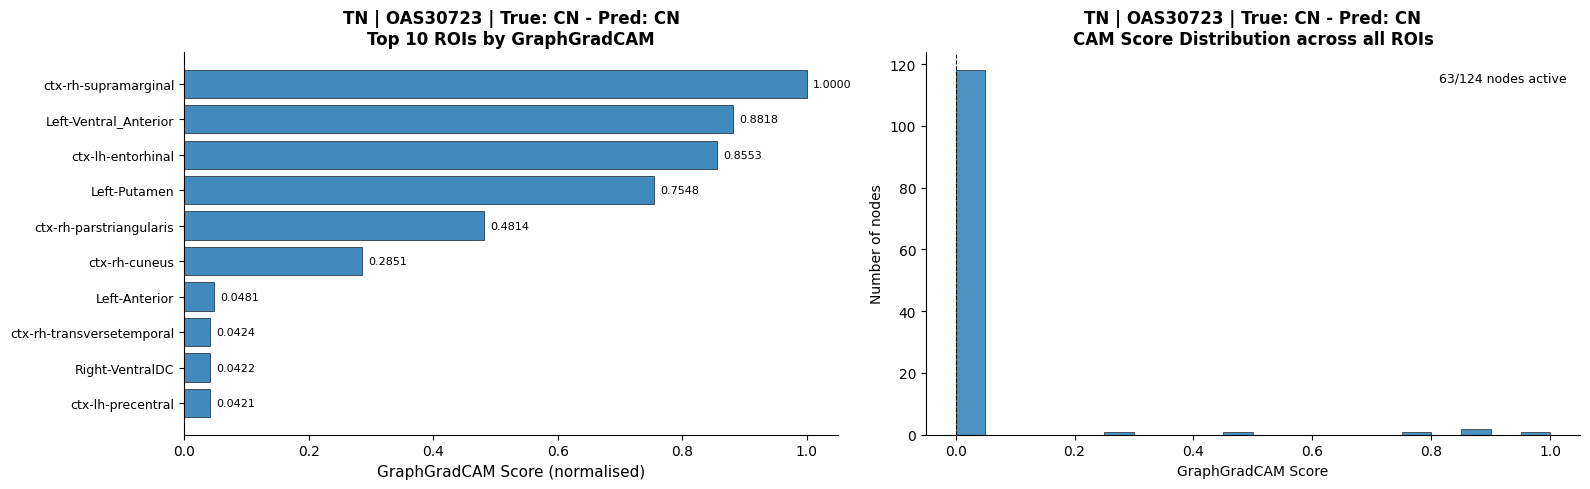


----------------------------------------------------------------------------------------------------

FP | OAS30443 | True: CN - Pred: MCI
  Active nodes (score > 0): 25 / 124
  Top 10 ROIs:
    Rank 01 | Right-Medio_Dorsal                            | 1.000000
    Rank 02 | Right-Ventral_Latero_Dorsal                   | 0.517992
    Rank 03 | ctx-lh-paracentral                            | 0.101097
    Rank 04 | ctx-lh-caudalanteriorcingulate                | 0.098640
    Rank 05 | ctx-lh-frontalpole                            | 0.092660
    Rank 06 | Left-Hippocampus_Fimbria                      | 0.017400
    Rank 07 | ctx-rh-pericalcarine                          | 0.007692
    Rank 08 | ctx-lh-isthmuscingulate                       | 0.007065
    Rank 09 | Right-Ventral_Anterior                        | 0.006113
    Rank 10 | ctx-lh-bankssts                               | 0.005496


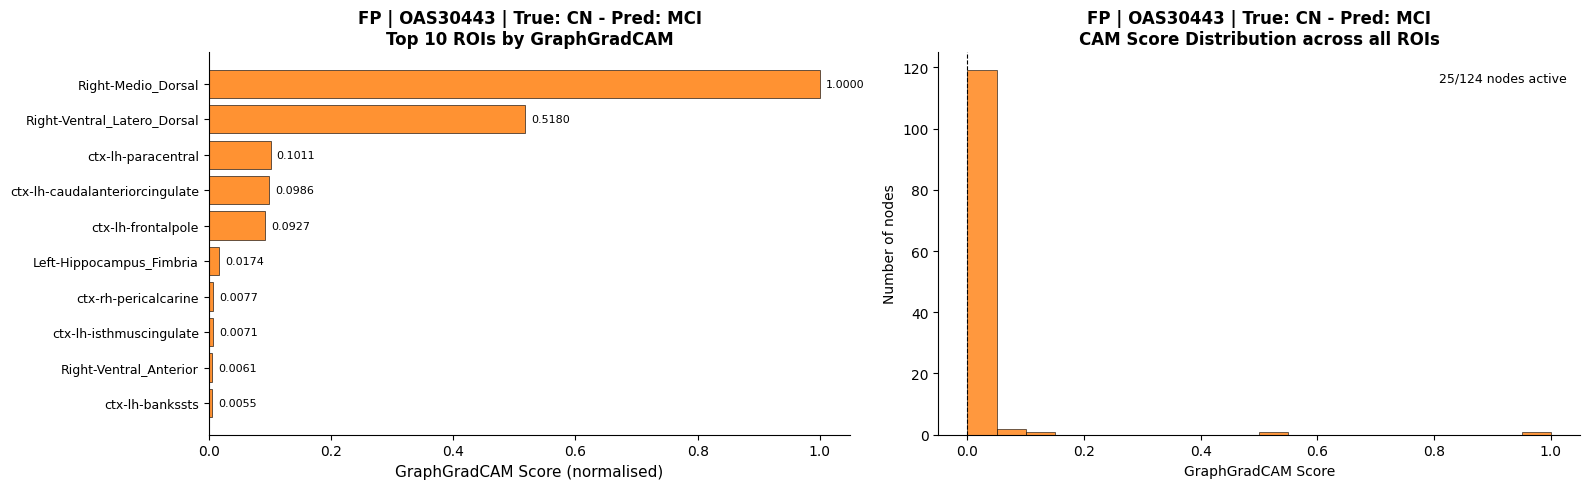


----------------------------------------------------------------------------------------------------

FN | OAS31050 | True: MCI - Pred: CN
  Active nodes (score > 0): 94 / 124
  Top 10 ROIs:
    Rank 01 | ctx-lh-superiorparietal                       | 1.000000
    Rank 02 | ctx-rh-pericalcarine                          | 0.707654
    Rank 03 | Left-Ventral_Latero_Dorsal                    | 0.570468
    Rank 04 | ctx-lh-precuneus                              | 0.247834
    Rank 05 | ctx-lh-lateralorbitofrontal                   | 0.231179
    Rank 06 | ctx-rh-bankssts                               | 0.227036
    Rank 07 | Left-VentralDC                                | 0.166555
    Rank 08 | ctx-lh-postcentral                            | 0.151272
    Rank 09 | ctx-rh-transversetemporal                     | 0.147439
    Rank 10 | Left-Hippocampus_HATA                         | 0.140126


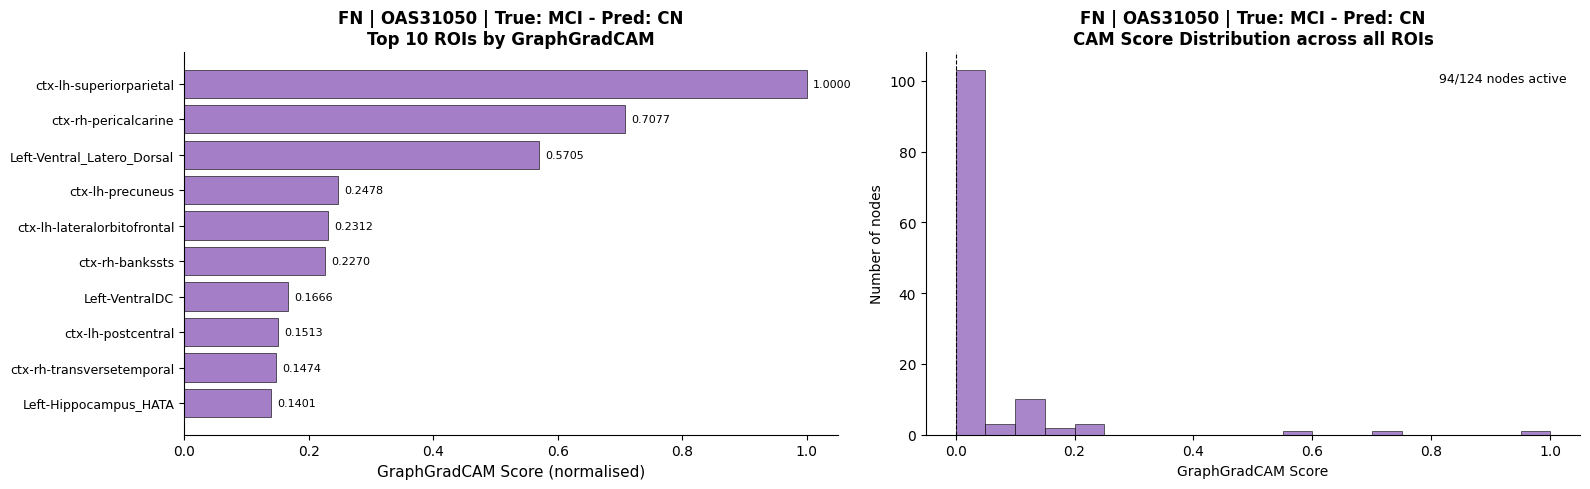

In [10]:
case_subjects = {}
for tag, pool in [('TP', TP), ('TN', TN), ('FP', FP), ('FN', FN)]:
    if not pool:
        print(f'{tag}: no subjects, skipping.')
        continue
    g, true, pred, prob_mci = pool[0]
    print(f'\n{"-"*100}')
    cam_scores = run_full_analysis(g, true, pred, tag)
    case_subjects[tag] = {
        'graph': g, 'true': true, 'pred': pred, 'cam_scores': cam_scores
    }

### Graph GradCAM analysis averaged across all subjects per prediction outcome

In [11]:
def run_gradcam_population(result_pool, pred_label, tag):
    '''
    Runs GraphGradCAM on every subject in result_pool.
    CAM scores are normalised per subject before averaging,
    so subjects with strong activations don't dominate.
    Returns mean CAM scores of shape (num_nodes,).
    '''
    all_cams = []
    for g, true, pred, prob_mci in result_pool:
        cam = run_graphgradcam(g, target_class=pred_label)
        all_cams.append(cam)
    mean_cam = np.stack(all_cams).mean(axis=0)
    print(f'{tag} (n={len(result_pool)}): population GradCAM done.')
    return mean_cam


pop_results = {}
for tag, pool, pred_l in [
    ('TP', TP, 1),
    ('TN', TN, 0),
    ('FP', FP, 1),
    ('FN', FN, 0),
]:
    if not pool:
        print(f'{tag}: no subjects, skipping.')
        continue
    mean_cam = run_gradcam_population(pool, pred_l, tag)
    pop_results[tag] = {'mean_cam': mean_cam, 'n': len(pool)}

TP (n=14): population GradCAM done.
TN (n=87): population GradCAM done.
FP (n=18): population GradCAM done.
FN (n=8): population GradCAM done.


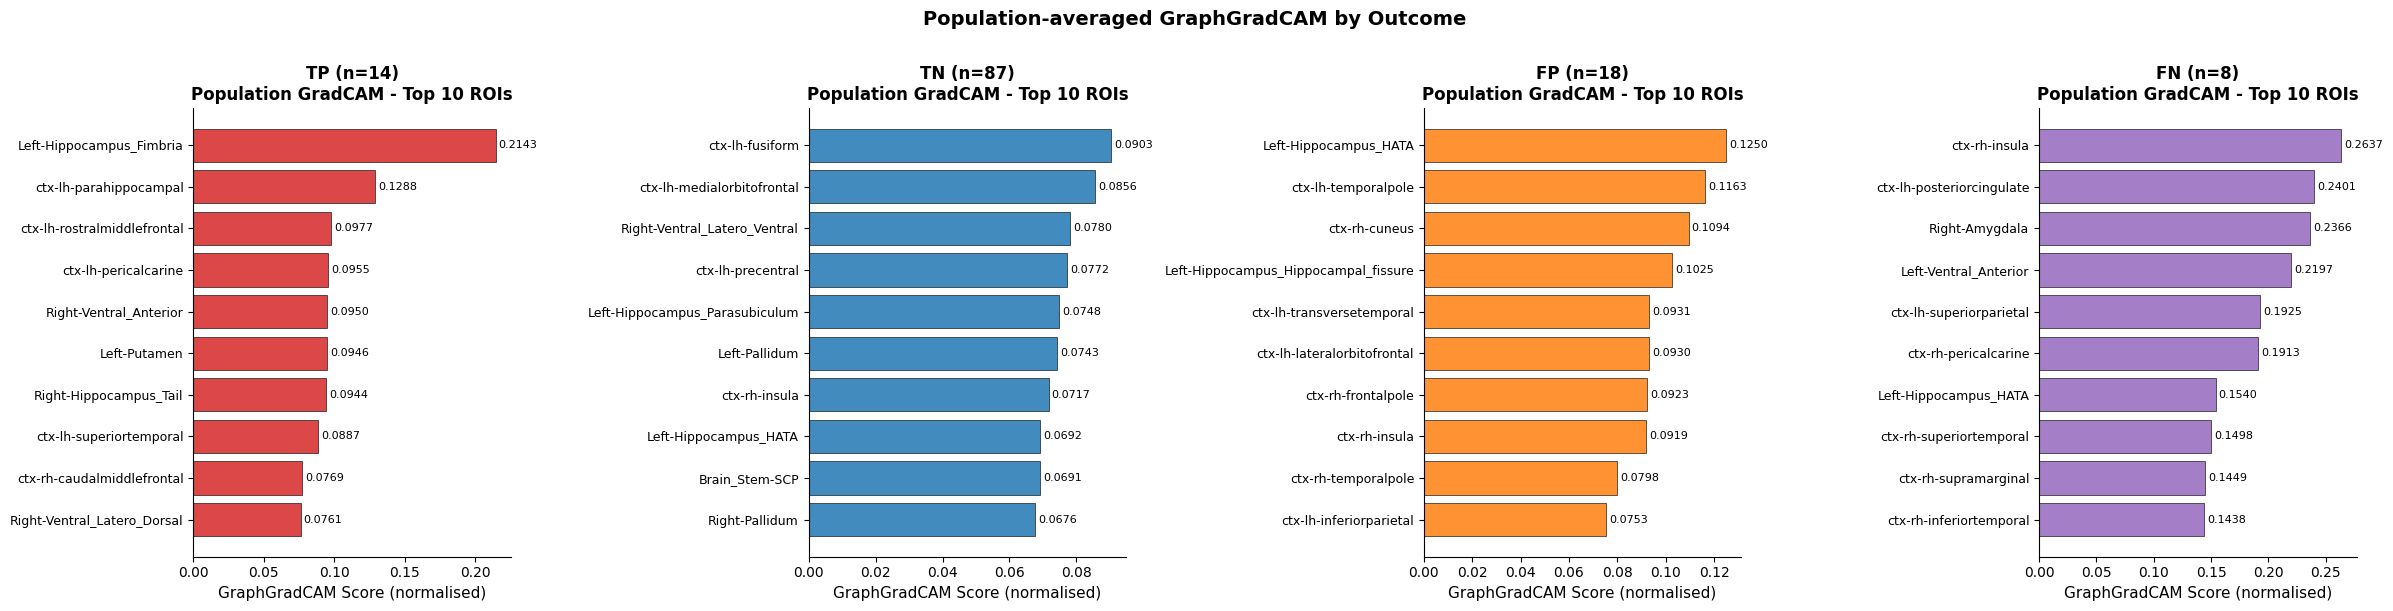

In [12]:
# population-level top ROIs for all four outcomes
colors          = {'TP': '#d62728', 'TN': '#1f77b4', 'FP': '#ff7f0e', 'FN': '#9467bd'}
available_tags  = [t for t in ['TP', 'TN', 'FP', 'FN'] if t in pop_results]

fig, axes = plt.subplots(1, len(available_tags), figsize=(6 * len(available_tags), 6))
if len(available_tags) == 1:
    axes = [axes]

for ax, tag in zip(axes, available_tags):
    mean_cam = pop_results[tag]['mean_cam']
    n        = pop_results[tag]['n']
    _, top_names, top_scores = get_top_nodes(mean_cam, node_labels)
    plot_top_nodes(ax, top_names, top_scores,
                   f'{tag} (n={n})\nPopulation GradCAM - Top 10 ROIs', colors[tag])

plt.suptitle('Population-averaged GraphGradCAM by Outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Population analysis per predicted class

In [13]:
# Group subjects by TRUE class label, regardless of prediction

class_pools = {
    'CN':  [(g, g.y.item(), *get_prediction(g)[:1], get_prediction(g)[2]) for g in cn_graphs],
    'MCI': [(g, g.y.item(), *get_prediction(g)[:1], get_prediction(g)[2]) for g in mci_graphs],
}
# Each entry: (graph, true_label, pred_label, prob_mci)

class_target = {'CN': 0, 'MCI': 1}
class_colors = {'CN': '#1f77b4', 'MCI': '#d62728'}

class_pop_results = {}
for cname, pool in class_pools.items():
    all_cams = []
    correct  = 0
    for g, true, pred, prob_mci in pool:
        cam = run_graphgradcam(g, target_class=class_target[cname])
        all_cams.append(cam)
        if pred == true:
            correct += 1
    mean_cam = np.stack(all_cams).mean(axis=0)
    class_pop_results[cname] = {
        'mean_cam': mean_cam,
        'all_cams': np.stack(all_cams),
        'n':        len(pool),
        'acc':      correct / len(pool) if pool else 0.0,
    }
    print(f'{cname}: n={len(pool)}  |  accuracy on this class = {correct}/{len(pool)} = {correct/len(pool):.3f}')

CN: n=105  |  accuracy on this class = 87/105 = 0.829
MCI: n=22  |  accuracy on this class = 14/22 = 0.636


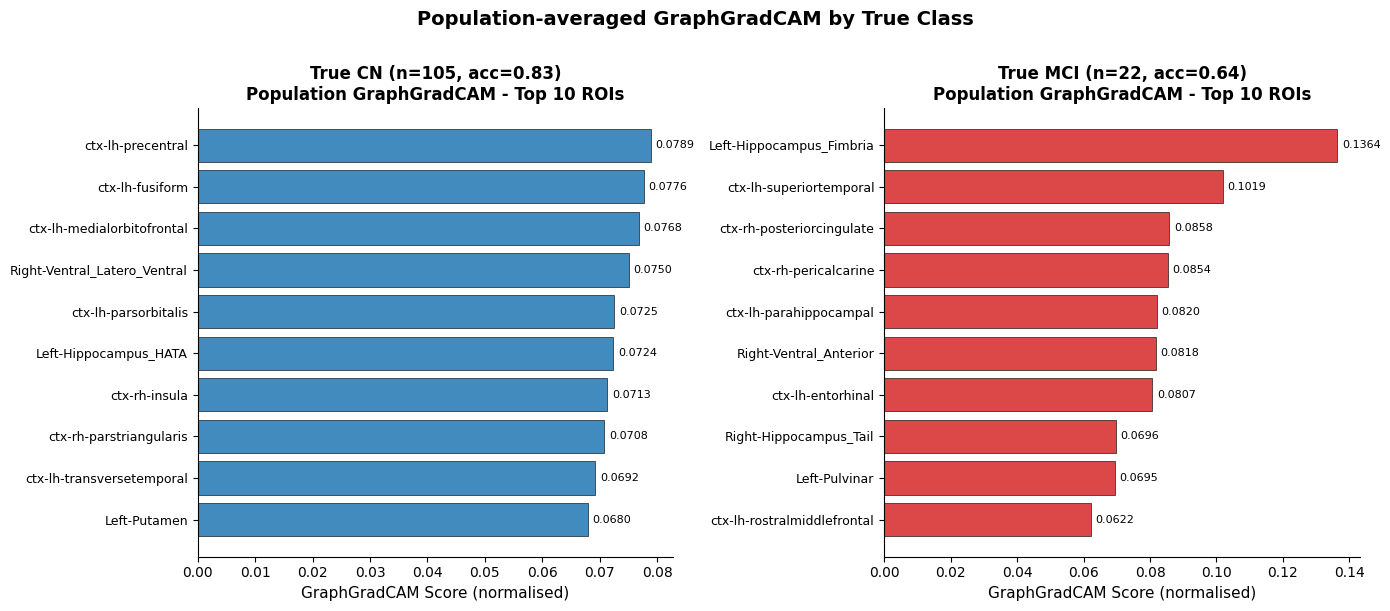

In [14]:
# Population-level top ROIs for each TRUE class
fig, axes = plt.subplots(1, len(class_pop_results), figsize=(7 * len(class_pop_results), 6))
if len(class_pop_results) == 1:
    axes = [axes]

for ax, cname in zip(axes, class_pop_results.keys()):
    mean_cam = class_pop_results[cname]['mean_cam']
    n        = class_pop_results[cname]['n']
    acc      = class_pop_results[cname]['acc']
    _, top_names, top_scores = get_top_nodes(mean_cam, node_labels)
    plot_top_nodes(ax, top_names, top_scores,
                   f'True {cname} (n={n}, acc={acc:.2f})\nPopulation GraphGradCAM - Top 10 ROIs',
                   class_colors[cname])

plt.suptitle('Population-averaged GraphGradCAM by True Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

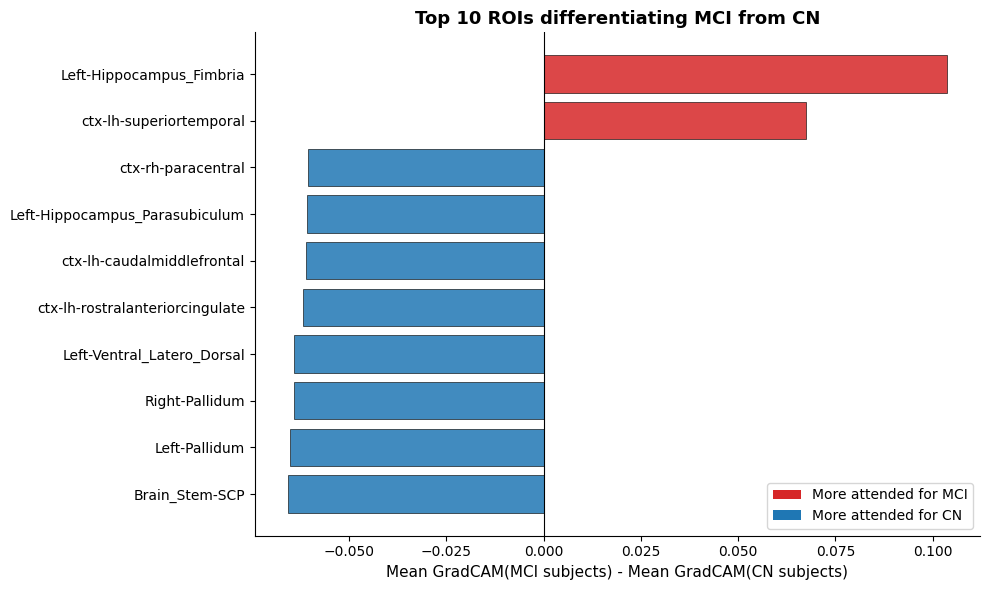


Top ROIs differentiating MCI vs CN:
  Left-Hippocampus_Fimbria                      | diff = +0.10369  (MCI)
  ctx-lh-superiortemporal                       | diff = +0.06739  (MCI)
  ctx-rh-paracentral                            | diff = -0.06046  (CN)
  Left-Hippocampus_Parasubiculum                | diff = -0.06077  (CN)
  ctx-lh-caudalmiddlefrontal                    | diff = -0.06122  (CN)
  ctx-lh-rostralanteriorcingulate               | diff = -0.06184  (CN)
  Left-Ventral_Latero_Dorsal                    | diff = -0.06405  (CN)
  Right-Pallidum                                | diff = -0.06407  (CN)
  Left-Pallidum                                 | diff = -0.06532  (CN)
  Brain_Stem-SCP                                | diff = -0.06580  (CN)


In [19]:
# Difference plot: which ROIs the model focuses on for MCI subjects vs CN subjects

if 'MCI' in class_pop_results and 'CN' in class_pop_results:
    diff = class_pop_results['MCI']['mean_cam'] - class_pop_results['CN']['mean_cam']

    # take top 10 by absolute difference
    top_abs_idx = np.argsort(np.abs(diff))[::-1][:10]
    top_names   = [node_labels[i] for i in top_abs_idx]
    top_vals    = diff[top_abs_idx]

    # sort for nicer display (largest positive on top)
    order       = np.argsort(top_vals)
    top_names   = [top_names[i] for i in order]
    top_vals    = top_vals[order]

    bar_colors  = [class_colors['MCI'] if v >= 0 else class_colors['CN'] for v in top_vals]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_names, top_vals, color=bar_colors, alpha=0.85,
            edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean GradCAM(MCI subjects) - Mean GradCAM(CN subjects)', fontsize=11)
    ax.set_title('Top 10 ROIs differentiating MCI from CN',
                 fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend_elems = [
        Patch(facecolor=class_colors['MCI'], label='More attended for MCI'),
        Patch(facecolor=class_colors['CN'],  label='More attended for CN'),
    ]
    ax.legend(handles=legend_elems, loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()

    print('\nTop ROIs differentiating MCI vs CN:')
    for name, val in zip(top_names[::-1], top_vals[::-1]):
        side = 'MCI' if val >= 0 else 'CN'
        print(f'  {name:<45s} | diff = {val:+.5f}  ({side})')

### Signed analysis

In [16]:
def run_graphgradcam_signed(subject, target_class=1):
    '''
    Same as run_graphgradcam but WITHOUT the ReLU, so the sign survives.
    By convention we use target_class=1 (MCI), so:
        score > 0  => node pushes the MCI logit UP    (supports MCI)
        score < 0  => node pushes the MCI logit DOWN  (supports CN)
    Scores are normalised by the max absolute value so the range is [-1, 1].
    '''
    model.eval()
    subject = subject.to(device)
    batch   = torch.zeros(subject.x.size(0), dtype=torch.long, device=device)

    activations = {}
    gradients   = {}

    def forward_hook(module, input, output):
        activations['conv2'] = output

    def backward_hook(module, grad_input, grad_output):
        gradients['conv2'] = grad_output[0]

    fwd_handle = model.conv2.register_forward_hook(forward_hook)
    bwd_handle = model.conv2.register_full_backward_hook(backward_hook)

    logits = model(subject.x, subject.edge_index, subject.edge_attr, batch)
    model.zero_grad()
    logits[0, target_class].backward()

    fwd_handle.remove()
    bwd_handle.remove()

    H = activations['conv2'].detach()
    G = gradients['conv2'].detach()

    # NO ReLU - keep the sign
    cam = (H * G).sum(dim=-1)            # (num_nodes,)
    cam_scores = cam.cpu().numpy()

    denom = np.abs(cam_scores).max()
    if denom > 0:
        cam_scores = cam_scores / denom  # now in [-1, 1]

    return cam_scores


print('Signed GraphGradCAM ready.')

Signed GraphGradCAM ready.



----------------------------------------------------------------------------------------------------

TP | OAS31004 | True: MCI - Pred: MCI  [signed, target=MCI]
  Top 10 contributors TOWARD MCI:
    +01 | ctx-rh-pericalcarine                          | +1.00000
    +02 | Right-Ventral_Anterior                        | +0.65542
    +03 | ctx-lh-entorhinal                             | +0.51769
    +04 | ctx-rh-parsorbitalis                          | +0.17829
    +05 | ctx-rh-caudalanteriorcingulate                | +0.10868
    +06 | ctx-rh-parahippocampal                        | +0.06740
    +07 | ctx-rh-middletemporal                         | +0.05058
    +08 | ctx-lh-lateraloccipital                       | +0.01348
    +09 | ctx-lh-fusiform                               | +0.01096
    +10 | Right-Pallidum                                | +0.00852
  Top 10 contributors TOWARD CN (negative for MCI):
    -01 | ctx-lh-inferiorparietal                       | -0.43503
    -02 | ctx-

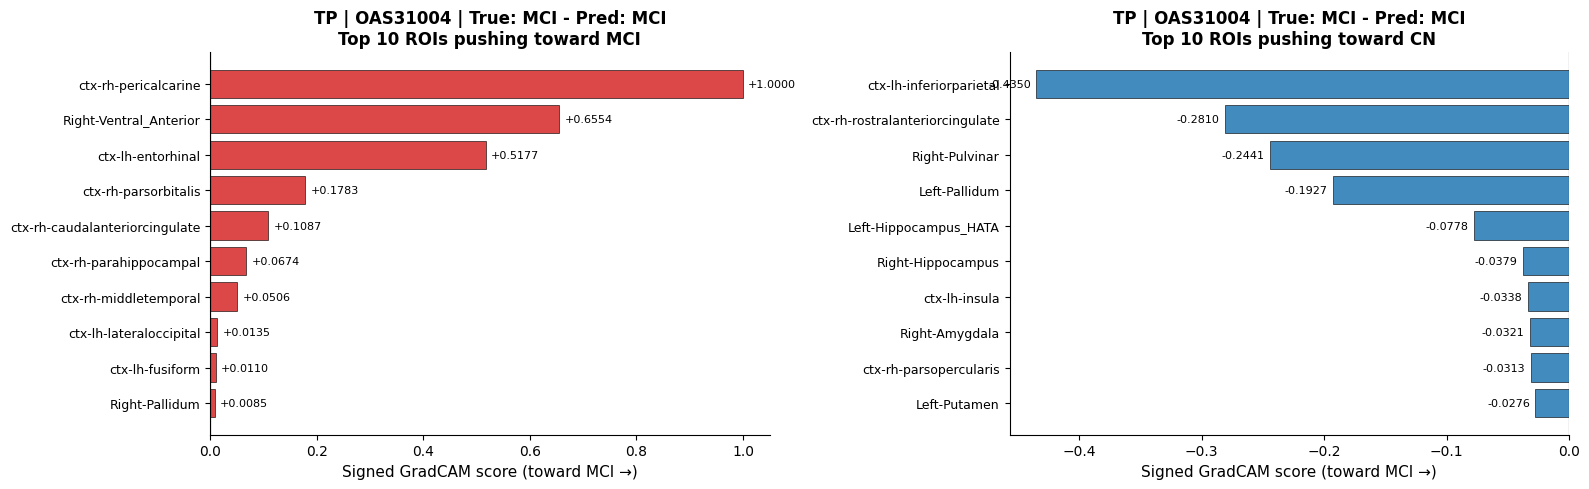


----------------------------------------------------------------------------------------------------

TN | OAS30723 | True: CN - Pred: CN  [signed, target=MCI]
  Top 10 contributors TOWARD MCI:
    +01 | Right-Hippocampus_HATA                        | +0.43240
    +02 | ctx-rh-cuneus                                 | +0.12018
    +03 | ctx-lh-caudalmiddlefrontal                    | +0.08813
    +04 | ctx-rh-rostralmiddlefrontal                   | +0.08106
    +05 | Right-Caudate                                 | +0.01188
    +06 | ctx-lh-precuneus                              | +0.00515
    +07 | Left-Hippocampus_Tail                         | +0.00262
    +08 | ctx-lh-posteriorcingulate                     | +0.00241
    +09 | ctx-lh-frontalpole                            | +0.00059
    +10 | ctx-lh-pericalcarine                          | +0.00016
  Top 10 contributors TOWARD CN (negative for MCI):
    -01 | ctx-rh-supramarginal                          | -1.00000
    -02 | ctx-lh

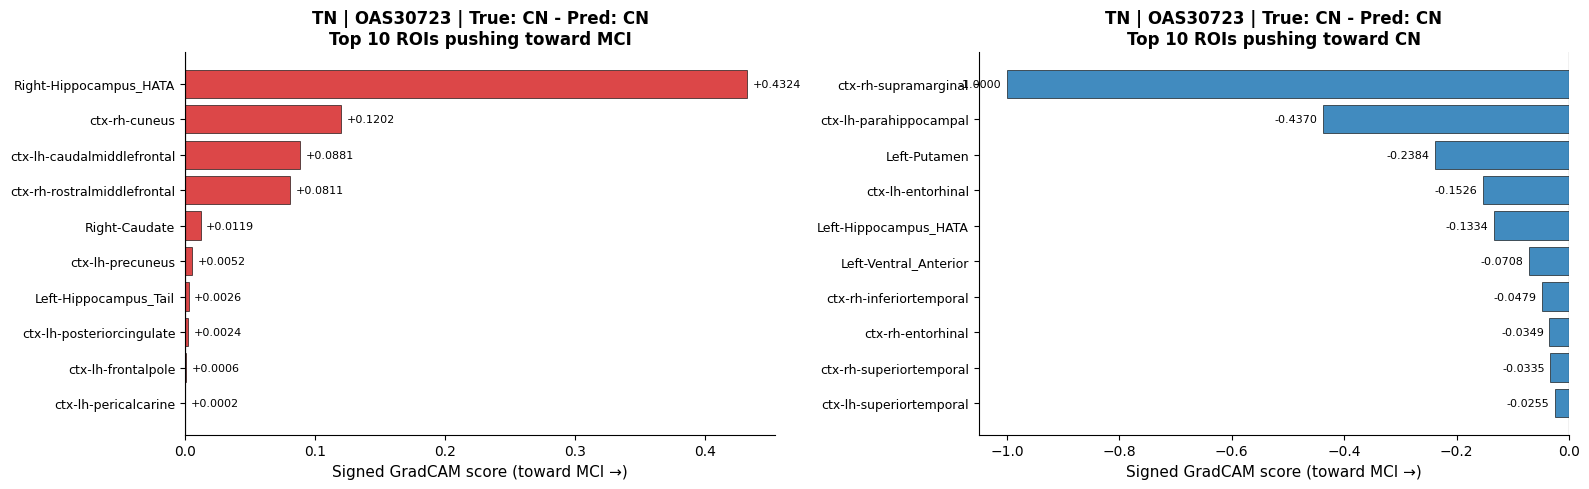


----------------------------------------------------------------------------------------------------

FP | OAS30443 | True: CN - Pred: MCI  [signed, target=MCI]
  Top 10 contributors TOWARD MCI:
    +01 | Right-Medio_Dorsal                            | +1.00000
    +02 | Right-Ventral_Latero_Dorsal                   | +0.51799
    +03 | ctx-lh-paracentral                            | +0.10110
    +04 | ctx-lh-caudalanteriorcingulate                | +0.09864
    +05 | ctx-lh-frontalpole                            | +0.09266
    +06 | Left-Hippocampus_Fimbria                      | +0.01740
    +07 | ctx-rh-pericalcarine                          | +0.00769
    +08 | ctx-lh-isthmuscingulate                       | +0.00707
    +09 | Right-Ventral_Anterior                        | +0.00611
    +10 | ctx-lh-bankssts                               | +0.00550
  Top 10 contributors TOWARD CN (negative for MCI):
    -01 | ctx-lh-lingual                                | -0.14567
    -02 | Right

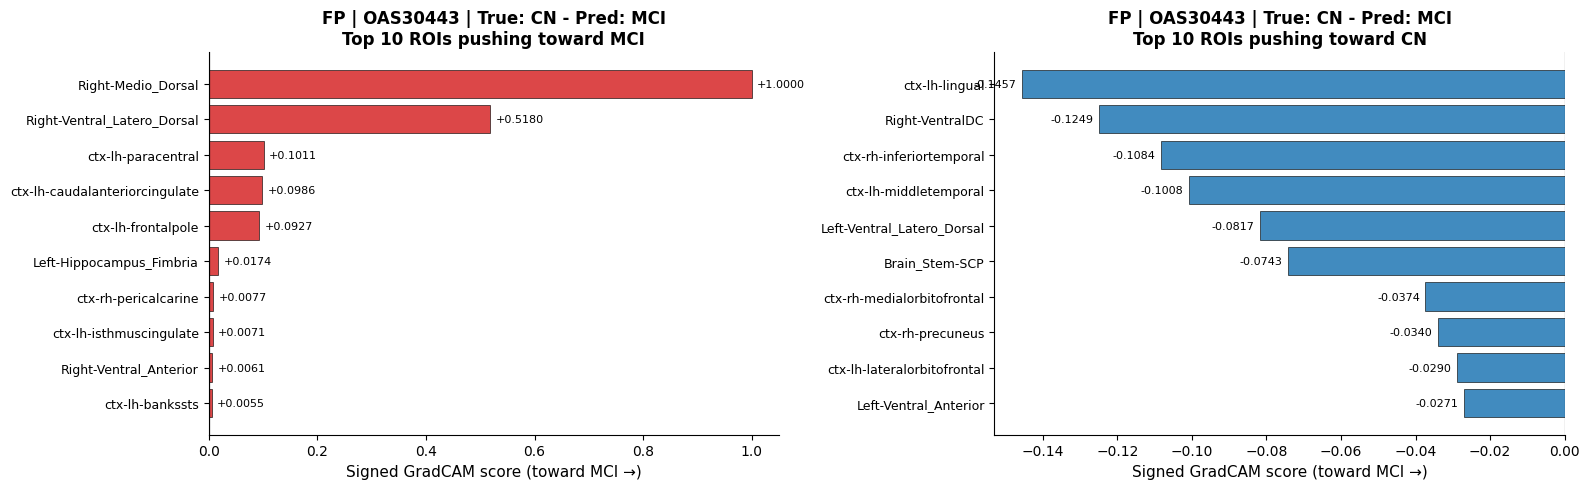


----------------------------------------------------------------------------------------------------

FN | OAS31050 | True: MCI - Pred: CN  [signed, target=MCI]
  Top 10 contributors TOWARD MCI:
    +01 | ctx-lh-superiortemporal                       | +0.98160
    +02 | ctx-rh-pericalcarine                          | +0.86244
    +03 | Right-Hippocampus_Hippocampal_fissure         | +0.46632
    +04 | ctx-rh-posteriorcingulate                     | +0.45464
    +05 | ctx-rh-lingual                                | +0.38138
    +06 | ctx-rh-middletemporal                         | +0.18851
    +07 | ctx-rh-caudalmiddlefrontal                    | +0.00428
    +08 | Left-Hippocampus_CA1                          | -0.00346
    +09 | Right-Hippocampus_GCDG                        | -0.00346
    +10 | Left-Hippocampus_Subiculum                    | -0.00346
  Top 10 contributors TOWARD CN (negative for MCI):
    -01 | ctx-rh-superiorfrontal                        | -1.00000
    -02 | Right

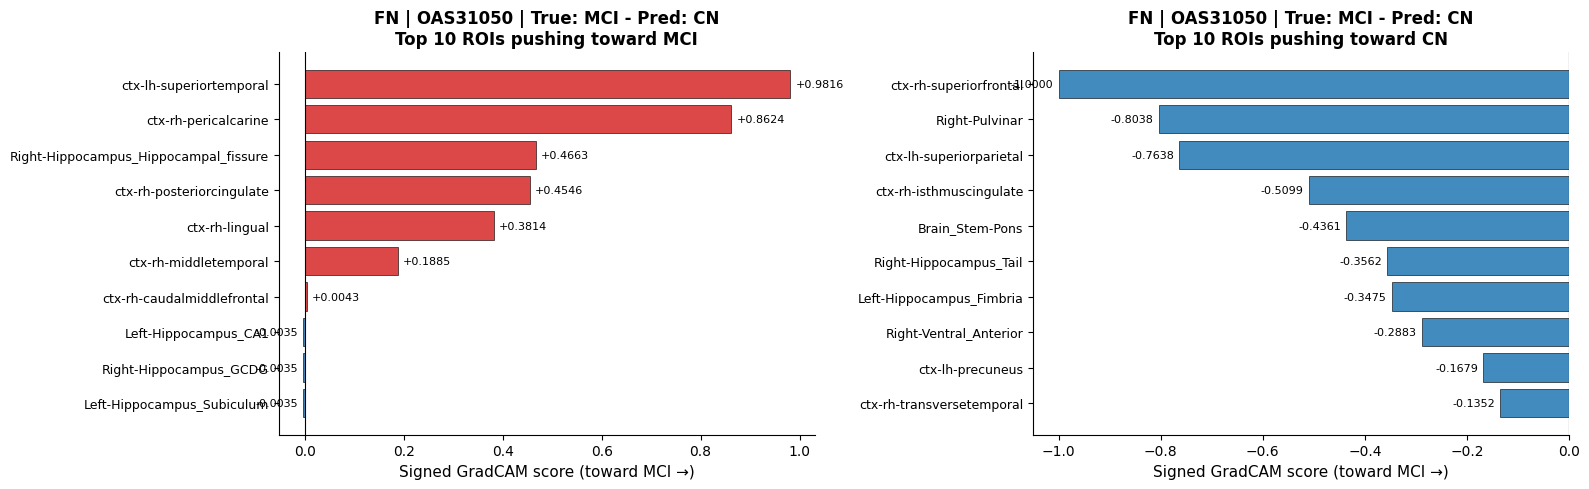

In [17]:
def plot_signed_top_nodes(ax, names, scores, title):
    '''Diverging barplot: red for positive (MCI), blue for negative (CN).'''
    names  = list(names[::-1])
    scores = list(scores[::-1])
    colors = [class_colors['MCI'] if s >= 0 else class_colors['CN'] for s in scores]
    ax.barh(names, scores, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Signed GradCAM score (toward MCI →)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)
    for y, s in enumerate(scores):
        offset = max(np.abs(scores)) * 0.01
        ha = 'left' if s >= 0 else 'right'
        ax.text(s + (offset if s >= 0 else -offset), y, f'{s:+.4f}',
                va='center', ha=ha, fontsize=8)


def run_signed_analysis(subject, true_label, pred_label, outcome_tag, top_n=10):
    '''
    Signed GradCAM for a single subject. Always explains class MCI (=1)
    so positive/negative have the same meaning regardless of the case.
    '''
    class_names = {0: 'CN', 1: 'MCI'}
    signed = run_graphgradcam_signed(subject, target_class=1)

    pos_idx = np.argsort(signed)[::-1][:top_n]      # most positive
    neg_idx = np.argsort(signed)[:top_n]            # most negative

    title_base = (f'{outcome_tag} | {subject.subject_id} | '
                  f'True: {class_names[true_label]} - Pred: {class_names[pred_label]}')

    print(f'\n{title_base}  [signed, target=MCI]')
    print(f'  Top {top_n} contributors TOWARD MCI:')
    for r, i in enumerate(pos_idx):
        print(f'    +{r+1:02d} | {node_labels[i]:<45s} | {signed[i]:+.5f}')
    print(f'  Top {top_n} contributors TOWARD CN (negative for MCI):')
    for r, i in enumerate(neg_idx):
        print(f'    -{r+1:02d} | {node_labels[i]:<45s} | {signed[i]:+.5f}')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_signed_top_nodes(axes[0],
                          [node_labels[i] for i in pos_idx], signed[pos_idx],
                          f'{title_base}\nTop {top_n} ROIs pushing toward MCI')
    plot_signed_top_nodes(axes[1],
                          [node_labels[i] for i in neg_idx], signed[neg_idx],
                          f'{title_base}\nTop {top_n} ROIs pushing toward CN')
    plt.tight_layout()
    plt.show()

    return signed


# run signed analysis on the most-confident TP/TN/FP/FN subjects already chosen
signed_case_results = {}
for tag, pool in [('TP', TP), ('TN', TN), ('FP', FP), ('FN', FN)]:
    if not pool:
        continue
    g, true, pred, _ = pool[0]
    print(f'\n{"-"*100}')
    signed_case_results[tag] = run_signed_analysis(g, true, pred, tag)

CN: signed CAM computed for 105 subjects.
MCI: signed CAM computed for 22 subjects.


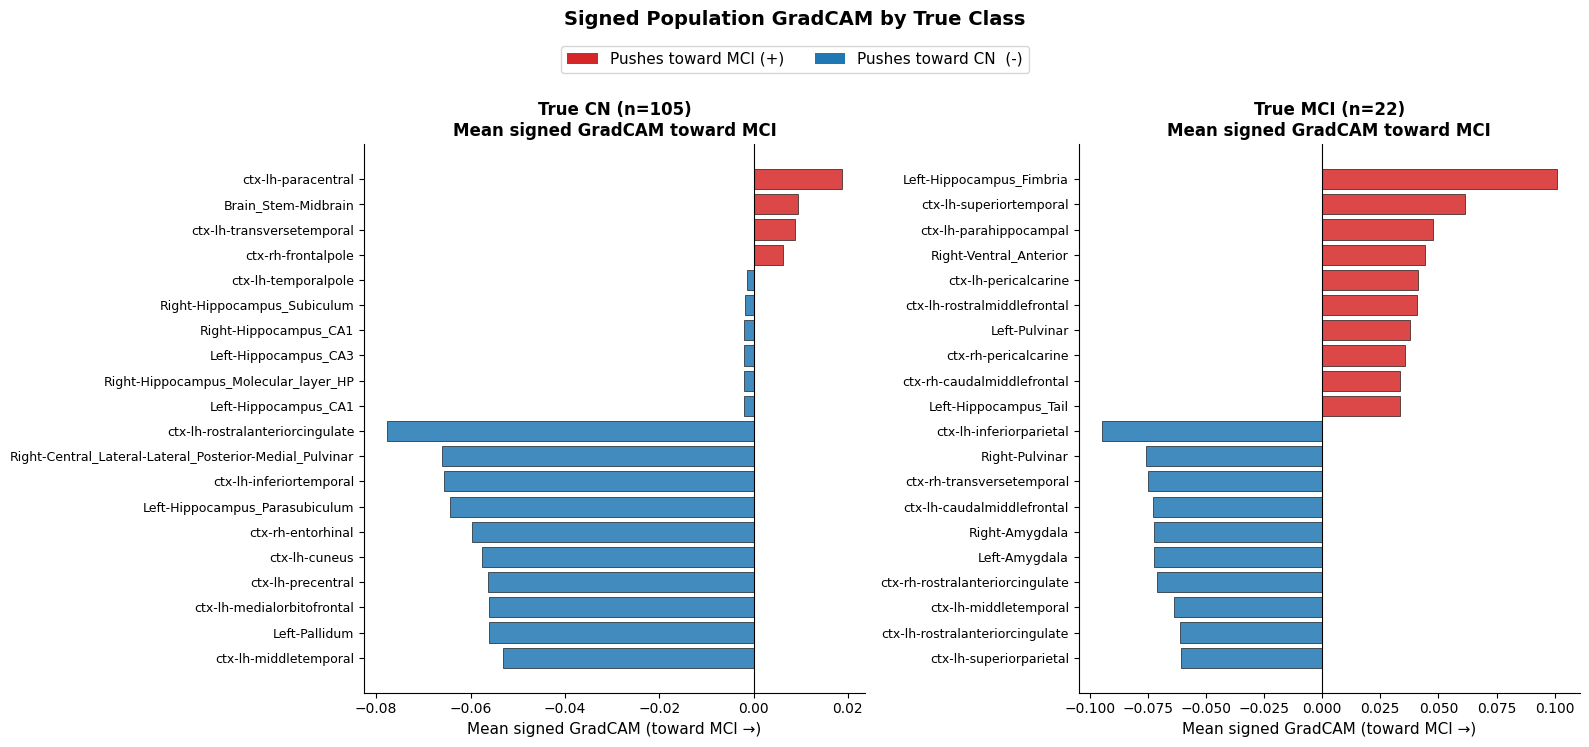


Overall mean signed CAM (target = MCI), top supporters and opposers:
  Pushes toward MCI:
    ctx-lh-transversetemporal                     | +0.01301
    ctx-lh-paracentral                            | +0.00941
    Brain_Stem-Midbrain                           | +0.00876
    Right-Hippocampus_Parasubiculum               | +0.00058
    ctx-lh-parahippocampal                        | -0.00007
    Right-Hippocampus_Subiculum                   | -0.00184
    Right-Hippocampus_CA1                         | -0.00187
    Left-Hippocampus_CA1                          | -0.00187
    Left-Hippocampus_CA3                          | -0.00187
    Left-Hippocampus_Molecular_layer_HP           | -0.00187
  Pushes toward CN:
    ctx-lh-rostralanteriorcingulate               | -0.07487
    Right-Central_Lateral-Lateral_Posterior-Medial_Pulvinar | -0.06199
    ctx-lh-inferiortemporal                       | -0.05901
    Left-Hippocampus_Parasubiculum                | -0.05563
    ctx-lh-middletemporal

In [18]:
# Population-level signed GradCAM, grouped by true class.
signed_class_results = {}
for cname, pool in class_pools.items():
    all_signed = []
    for g, true, pred, prob_mci in pool:
        all_signed.append(run_graphgradcam_signed(g, target_class=1))
    arr = np.stack(all_signed)              # (n_subjects, n_nodes)
    signed_class_results[cname] = {
        'mean':    arr.mean(axis=0),
        'std':     arr.std(axis=0),
        'all':     arr,
        'n':       len(pool),
    }
    print(f'{cname}: signed CAM computed for {len(pool)} subjects.')


def plot_signed_population(ax, mean_signed, title, top_n=10):
    pos_idx = np.argsort(mean_signed)[::-1][:top_n]
    neg_idx = np.argsort(mean_signed)[:top_n]
    idx     = np.concatenate([neg_idx[::-1], pos_idx[::-1]])  # CN-side bottom, MCI-side top
    names   = [node_labels[i] for i in idx]
    vals    = mean_signed[idx]
    colors  = [class_colors['MCI'] if v >= 0 else class_colors['CN'] for v in vals]
    ax.barh(names, vals, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean signed GradCAM (toward MCI →)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)


fig, axes = plt.subplots(1, len(signed_class_results),
                         figsize=(8 * len(signed_class_results), 7))
if len(signed_class_results) == 1:
    axes = [axes]

for ax, cname in zip(axes, signed_class_results.keys()):
    n = signed_class_results[cname]['n']
    plot_signed_population(ax, signed_class_results[cname]['mean'],
                           f'True {cname} (n={n})\nMean signed GradCAM toward MCI')

legend_elems = [
    Patch(facecolor=class_colors['MCI'], label='Pushes toward MCI (+)'),
    Patch(facecolor=class_colors['CN'],  label='Pushes toward CN  (-)'),
]
fig.legend(handles=legend_elems, loc='upper center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Signed Population GradCAM by True Class', fontsize=14,
             fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()


# numeric summary across the whole test set (all subjects pooled)
all_signed_all = np.concatenate([signed_class_results[c]['all']
                                 for c in signed_class_results], axis=0)
overall_mean   = all_signed_all.mean(axis=0)

print('\nOverall mean signed CAM (target = MCI), top supporters and opposers:')
pos_idx = np.argsort(overall_mean)[::-1][:10]
neg_idx = np.argsort(overall_mean)[:10]
print('  Pushes toward MCI:')
for i in pos_idx:
    print(f'    {node_labels[i]:<45s} | {overall_mean[i]:+.5f}')
print('  Pushes toward CN:')
for i in neg_idx:
    print(f'    {node_labels[i]:<45s} | {overall_mean[i]:+.5f}')